## **Gini** **impurity**

### Properties



*   Gini = 0 ➡ Pure node
*   Higher Gini ➡ More mixed classes
*   Lower Gini ➡ Better split
*   Used by CART (Classification and Regression    Trees)

*   Default criterion in Scikit-Learn






## **Entropy**

Case 2: Pure Classes


          Pass         Fail
-------------------------------
          100%          0%

Every student belongs to the same class.

*   No uncertainty
*   Entropy is zero





*   Entropy = 0 → Pure node
*   Entropy = 1 → Maximum disorder (binary classes)
*   Lower entropy → Better node

# **Information Gain**

**Information Gain (IG)** measures how much information is gained after spliting a dataset.



##**Without** **Puring**


*   
*   
*   
*   

##**With Puring**



*   
*   
*   
*   



**Types of Puring**

1. Pre-Puring(Early Stopping)
2. Post-Puring

**1. Pre-Puring(Early Stopping)**



**2. Post-Puring**

*   In Post-Pruning, we first grow the complete tree.

*   Then we remove branches that do not improve model performance.

# Process:

1. Build the full tree

2. Evaluate branches

3. Remove branches with little contribution

4. Keep only useful splits

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# Load dataset
iris = load_iris()
x = iris.data
y = iris.target

# Create Decision Tree Model
dt = DecisionTreeClassifier(criterion = "gini", max_depth = 3)

# Train Model
dt  = dt.fit(x,y)

# Prediction
print(dt.predict([[5.1, 3.5, 1.4, 0.2]]))

[0]


## **Random Forest**

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve the accuracy and stability of predictions.

# **Bagging**

Bagging is an ensemble technique that trains multiple models independently on different bootstrap samples of the training data and then combines their predictions.


1. **Random selection** :  Some rows repeat, some are missing

2. **Train multiple models**:  We train a decision tree for each sample.

3. **Make predictions**:  Each tree gives its own answer.

4. **Combine results:**

Classification → Majority voting

Regression → Average

## **Out-Of-Bag(OOB) Error**

OOB error is a way to check model accuracy without using a separate test set

### **In Random Forest:**

*   Each tree is trained using a random sample of data

*   Some data points are **not used** for that tree
*   These unused data points are called **Out-of-Bag (OOB) samples**







In [ ]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Create Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,   # number of trees
    oob_score=True,     # enable Out-of-Bag error
    random_state=42
)

# Train model
rf.fit(X, y);

# 1. OOB Score (Out-of-Bag Accuracy)
print("OOB Accuracy:", rf.oob_score_)
print("OOB Error:", 1 - rf.oob_score_)

# 2. Feature Importance
importance = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": rf.feature_importances_
})
importance = importance.sort_values(by="Importance", ascending=False)
print("\nFeature Importance:")
print(importance)

# 3. Individual Prediction Example
sample = np.array([[5.1, 3.5, 1.4, 0.2]])
print("\nPrediction:", rf.predict(sample))

OOB Accuracy: 0.9533333333333334
OOB Error: 0.046666666666666634

Feature Importance:
             Feature  Importance
2  petal length (cm)    0.436130
3   petal width (cm)    0.436065
0  sepal length (cm)    0.106128
1   sepal width (cm)    0.021678

Prediction: [0]


# **Support Vector Machine**


Support Vector Machine (SVM) is a supervised machine learning algorithm used

for:

*   Classification
*   Regression
*   Outlier Detection

SVM is mainly used for classification problems.


# **Hyperplane**

a hyperplane is a decision boundary that seperates different classses.



Hyperplane in Different Dimensions

            **Number of Features**                      **Hyperplane**


------------------------------------------------------------------------------
              2 Features                                     Line

              3 Features                                     Plane
            
              n Features                                    Hyperplane

**Hyperplane Equation:**

The separating boundary is represented as:

                                        wˣx+b=0

Where:



*   **w** = Weights
*   **x** = Input Features
*   **b** = Bias

# **Margin**

**Goal of SVM**

Choose the hyperplane with the:

Maximum Margin

# **Kernal Trick**

The Kernel Trick transforms data into a higher-dimensional space where it becomes linearly separable.

Instead of explicitly calculating new coordinates, SVM uses a kernel function.


**TYPES:**

1. **Linear Kernal**:  ( used when data is already linearly separable)

▶ ADVANTAGES:
*   Simple
*   Fast
*   Good for High-Dimensional data

2. **Polynominal Kernal**: ( Creates curved decision boundaries )



▶ADVANTAGES:
*   
*   
*   

3. **RBF Kernal (Radial Basis Function ) :** ( Most commonly used kernal )

▶ADVANTAGES:
*   Handles complex datasets
*   Creates flexible decision boundaries
*   Default kernal is  Scikit-Learn

# **Matrix**:

1.Confusion Matrix

            **Predicted Positive **          ** Predicted Negative**


----------------------------------------------------------------------

          Actual Positive   TP                      FN
          Actual Negative   FP                      TN



*   TP = True Positive
*   TN = True Negative
*   FP = False Positive
*   FN = False Negative

2. Accuracy : ( Accuracy measures the proportion of correct prediction )



3. Precision : (Out of all predicted positives, how many are actually positive?)

              TP
Precision = --------

            TP+FP

4. Recall: (Out of all predicted positives, how many were correctly identified?)

          TP

Recall = -------

        TP + FN

5. F1 Score: (F1 score balances Precision and recall )

          Precision x Recall
F1 = 2 X ----------------------

          Precision + Recall

6.


Plots:

TPR (True Positive Rate)

FPR (False Positive Rate)

Where:


                          TPR = Recall


                                  FP

                        FPR= -----------------

                                FP+TN

7.AUC




                      AUC                  Meaning

                      0.0                Worst Model

                      0.5               Random Guessing

                      0.7                    Fair

                      0.8                    Good

                      0.9                 Excellent

                      1.0                Perfect Model

In [ ]:
# 1. IMPORT LIBRARIES
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)
import numpy as np

# 2. LOAD DATASET
iris = load_iris()
X = iris.data
y = iris.target

# 3. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 4. CREATE SVM MODEL
# kernel options: 'linear', 'rbf', 'poly', 'sigmoid'
svm = SVC(
    kernel='rbf',      # non-linear kernel
    probability=True,  # needed for ROC-AUC
    random_state=42
)

# 5. TRAIN MODEL
svm.fit(X_train, y_train)

# 6. PREDICTION
y_pred = svm.predict(X_test)
# probability scores (for ROC-AUC)
y_prob = svm.predict_proba(X_test)

# 7. EVALUATION METRICS
print("MODEL PERFORMANCE")
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
# Precision
precision = precision_score(y_test, y_pred, average='macro')
print("Precision:", precision)
# Recall
recall = recall_score(y_test, y_pred, average='macro')
print("Recall:", recall)
# F1 Score
f1 = f1_score(y_test, y_pred, average='macro')
print("F1 Score:", f1)
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)
# ROC-AUC (multi-class)
roc = roc_auc_score(y_test, y_prob, multi_class='ovr') #One-vs-Rest approach
print("\nROC-AUC Score:", roc)

# 8. SINGLE PREDICTION
sample = np.array([[5.1, 3.5, 1.4, 0.2]])
prediction = svm.predict(sample)
print("\nSingle Sample Prediction:", prediction)

MODEL PERFORMANCE
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

ROC-AUC Score: 1.0

Single Sample Prediction: [0]


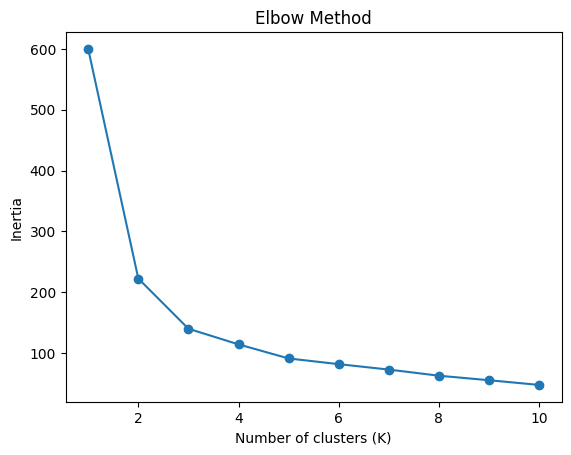

Silhouette Score: 0.45994823920518635


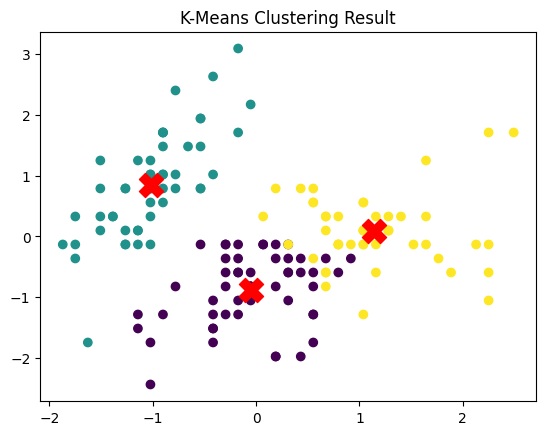

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# 1. Load dataset
iris = load_iris()
X = iris.data

# 2. Feature scaling (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Elbow Method (Inertia)
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.show()

# 4. Fit final KMeans (choose K = 3 for iris)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# 5. Silhouette Score
score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

# 6. Visualize clusters (first 2 features)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=300, c='red', marker='X')
plt.title("K-Means Clustering Result")
plt.show()

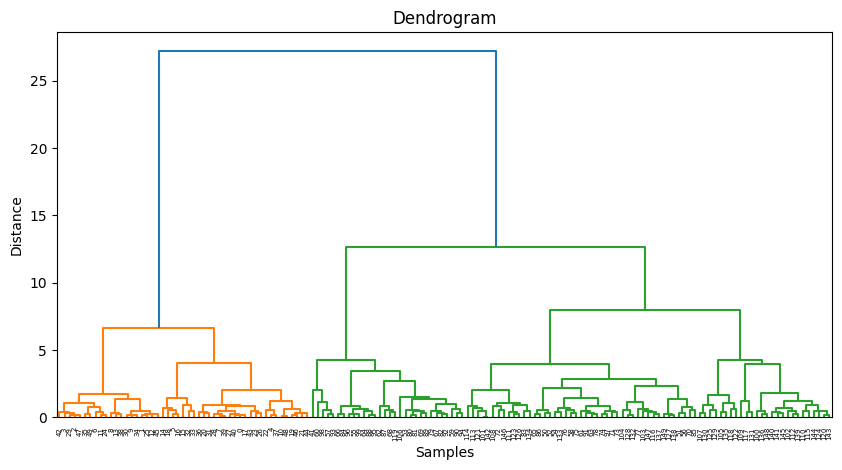

Cluster Labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 2 1 1 1 1 1 1 1 1 0 0 0 2 0 2 0 2 0 2 2 0 2 0 2 0 2 2 2 2 0 0 0 0
 0 0 0 0 0 2 2 2 2 0 2 0 0 2 2 2 2 0 2 2 2 2 2 0 2 2 0 0 0 0 0 0 2 0 0 0 0
 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Load dataset
iris = load_iris()
X = iris.data

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create linkage matrix
linked = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

# Hierarchical Clustering
hc = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)
labels = hc.fit_predict(X_scaled)
print("Cluster Labels:")
print(labels)